# 01 — Data Exploration & Profiling
**Objective:** Load the raw CEMS datasets, inspect their structure, and systematically discover all data quality issues before any cleaning.

We work with the **dev dataset (~6K rows)** for fast iteration.

---

## 1. Setup & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

# Style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
pd.set_option('display.width', 200)

print('Libraries loaded.')

C:\Users\KIIT\AppData\Local\Temp\ipykernel_31324\3020950035.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Libraries loaded.


In [2]:
# ── Load all 5 datasets ──
DATA_DIR = '../datasets/dev'

raw = pd.read_csv(f'{DATA_DIR}/raw_cems_data.csv')
sensors = pd.read_csv(f'{DATA_DIR}/sensor_master.csv')
maint = pd.read_csv(f'{DATA_DIR}/maintenance_logs.csv')
manual = pd.read_csv(f'{DATA_DIR}/manual_entries.csv')
thresholds = pd.read_csv(f'{DATA_DIR}/regulatory_thresholds.csv')

print(f'raw_cems_data   : {raw.shape[0]:,} rows x {raw.shape[1]} cols')
print(f'sensor_master   : {sensors.shape[0]:,} rows x {sensors.shape[1]} cols')
print(f'maintenance_logs: {maint.shape[0]:,} rows x {maint.shape[1]} cols')
print(f'manual_entries  : {manual.shape[0]:,} rows x {manual.shape[1]} cols')
print(f'reg_thresholds  : {thresholds.shape[0]:,} rows x {thresholds.shape[1]} cols')

raw_cems_data   : 5,650 rows x 11 cols
sensor_master   : 10 rows x 9 cols
maintenance_logs: 6 rows x 5 cols
manual_entries  : 10 rows x 5 cols
reg_thresholds  : 6 rows x 3 cols


## 2. First Look — Shape & Schema
Let's inspect the raw CEMS data first since it's the primary dataset.

In [3]:
# Quick overview of the main dataset
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5650 entries, 0 to 5649
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Record_ID        5650 non-null   object 
 1   Plant_ID         5650 non-null   object 
 2   Stack_ID         5650 non-null   object 
 3   Flow_Rate_m3_hr  4536 non-null   float64
 4   TS               5650 non-null   object 
 5   PM2.5            5564 non-null   object 
 6   SO2              5545 non-null   object 
 7   NOx              5578 non-null   object 
 8   Unit             5650 non-null   object 
 9   Status           5624 non-null   object 
 10  Lat_Lon          5650 non-null   object 
dtypes: float64(1), object(10)
memory usage: 485.7+ KB


In [4]:
# First 20 rows to visually scan for obvious issues
raw.head(20)

,Record_ID,Plant_ID,Stack_ID,Flow_Rate_m3_hr,TS,PM2.5,SO2,NOx,Unit,Status,Lat_Lon
0,E00001,PL-01,S-01,2201.9,01-01-2025 00:00,125.3,NaN,-3.4,ug/m3,OK,"13.0834,80.271"
1,E00002,PL-01,S-02,1881.1,01/01/2025 00:00,153.7,30.5,92.7,ug/m3,maint,"13.0834,80.2721"
2,E00004,PL-03,S-01,1712.5,01-01-2025 00:00,261.4,200.3,7777.0,mg/Nm3,OK,"12.9726,77.5952"
3,E00005,PL-03,S-02,2838.9,01-01-2025 00:00,103.8,118.6,211.1,ug/m3,ok,"12.9718,77.5958"
4,E00007,LOC-DEL-01,A-01,NaN,01-01-2025 00:00,70.5,25.2,139.9,ug/m3,OK,"28.6137,77.2081"
5,E00008,LOC-DEL-02,A-02,0.0,01-01-2025 00:00,121.7,157.7,140.5,ug/m3,FAULT,"28.6205,77.2159"
6,E00009,LOC-MUM-01,A-01,NaN,01-01-2025 00:00,97.3,45.1,BDL,µg/m³,OK,"19.0764,72.8781"
7,E00010,LOC-BLR-01,A-01,0.0,01-01-2025 00:00,195.4,63.5,211.0,ug/m3,MAINT,"12.9726,77.5939"
8,E00011,PL-01,S-01,2077.8,01-01-2025 00:15,149.5,211.0,50.4,µg/m³,FAULT,"13.0819,80.2702"
9,E00012,PL-01,S-02,1321.2,01-01-2025 00:15,183.3,88.2,203.9,ug/m3,FAULT,"13.0829,80.2708"


In [5]:
# Tail too — check for end-of-file weirdness
raw.tail(10)

,Record_ID,Plant_ID,Stack_ID,Flow_Rate_m3_hr,TS,PM2.5,SO2,NOx,Unit,Status,Lat_Lon
5640,E05990,LOC-BLR-01,A-01,NaN,07-01-2025 05:30,49.0,255.8,121.5,µg/m³,OK,"12.9718,77.5948"
5641,E05991,PL-01,S-01,2460.9,07-01-2025 05:45,212.0,-7.1,87.5,ug/m3,FAULT,"13.0822,80.2714"
5642,E05992,PL-01,S-02,1416.8,07-01-2025 05:45,NaN,22.3,23.0,ug/m3,FAULT,"13.0826,80.271"
5643,E05993,PL-02,S-01,4123.0,07-01-2025 05:45,68.0,136.2,132.1,ug/m3,Ok,"19.0762,72.8779"
5644,E05995,PL-03,S-02,4338.9,07-01-2025 05:45,188.7,15.0,168.5,ug/m3,MAINT,"12.9711,77.5944"
5645,E05996,PL-03,S-03,3981.4,07-01-2025 00:15 UTC,169.1,201.0,86.7,ug/m3,FAULT,"12.9713,77.5955"
5646,E05997,LOC-DEL-01,A-01,0.0,07-01-2025 05:45,149.5,-13.5,132.8,ug/m3,OK,"28.6136,77.2097"
5647,E05998,LOC-DEL-02,A-02,0.0,07-01-2025 05:45,103.1,94.3,92.7,ug/m3,DOWN,"28.619,77.2156"
5648,E05999,LOC-MUM-01,A-01,0.0,07-01-2025 05:45,113.4,47.0,160.8,mg/Nm3,FAULT,"19.0759,72.8772"
5649,E06000,LOC-BLR-01,A-01,NaN,06-01-2025 24:45,89.7,169.7,26.8,ug/m3,fault,"12.9719,77.5941"


In [6]:
# Basic statistics for numeric-looking columns
# Note: PM2.5, SO2, NOx are 'object' dtype if they contain BDL strings!
raw.describe(include='all')

,Record_ID,Plant_ID,Stack_ID,Flow_Rate_m3_hr,TS,PM2.5,SO2,NOx,Unit,Status,Lat_Lon
count,5650,5650,5650,4536.000000,5650,5564,5545,5578,5650,5624,5650
unique,5650,7,5,NaN,1178,2039,2051,2029,3,17,2053
top,E00001,PL-03,A-01,NaN,03-01-2025 24:30,15.0,15.0,15.0,ug/m3,MAINT,"12.9716,77.5943"
freq,1,1688,1697,NaN,12,132,139,130,4521,1320,14
mean,NaN,NaN,NaN,2250.067130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,1654.721018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,2318.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,3692.800000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missing Values Analysis

In [7]:
# Count nulls per column
null_counts = raw.isnull().sum()
null_pct = (null_counts / len(raw) * 100).round(2)

null_report = pd.DataFrame({
    'Null_Count': null_counts,
    'Null_%': null_pct
})

print('=== Null Values Report ===')
print(null_report)
print(f'\nTotal rows: {len(raw):,}')

=== Null Values Report ===
                 Null_Count  Null_%
Record_ID                 0    0.00
Plant_ID                  0    0.00
Stack_ID                  0    0.00
Flow_Rate_m3_hr        1114   19.72
TS                        0    0.00
PM2.5                    86    1.52
SO2                     105    1.86
NOx                      72    1.27
Unit                      0    0.00
Status                   26    0.46
Lat_Lon                   0    0.00

Total rows: 5,650


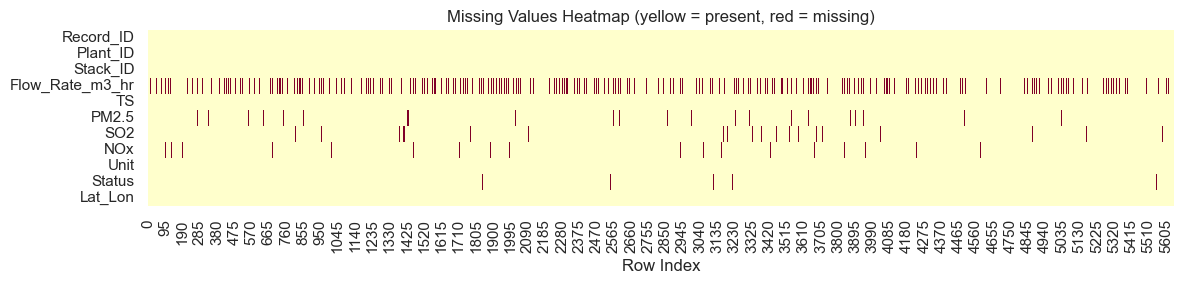

In [8]:
# Visual null pattern
fig, ax = plt.subplots(figsize=(12, 3))
sns.heatmap(raw.isnull().T, cbar=False, cmap='YlOrRd', ax=ax)
ax.set_title('Missing Values Heatmap (yellow = present, red = missing)')
ax.set_xlabel('Row Index')
plt.tight_layout()
plt.show()

## 4. Timestamp (`TS`) Analysis
The `TS` column should be a proper datetime. Let's check what formats are actually in the data.

In [9]:
# Check samples
print('Sample TS values:')
print(raw['TS'].head(20).tolist())

Sample TS values:
['01-01-2025 00:00', '01/01/2025 00:00', '01-01-2025 00:00', '01-01-2025 00:00', '01-01-2025 00:00', '01-01-2025 00:00', '01-01-2025 00:00', '01-01-2025 00:00', '01-01-2025 00:15', '01-01-2025 00:15', '01-01-2025 00:15', '01-01-2025 00:15', '01-01-2025 00:15', '01-01-2025 00:15', '01-01-2025 00:15', '01-01-2025 00:15', '01-01-2025 00:15', '01-01-2025 00:15', '01/01/2025 00:30', '01-01-2025 00:30']


In [10]:
# Detect timestamps with hour=24 (midnight rollover issue)
ts_24 = raw['TS'].str.contains(r'\b24:\d{2}', na=False, regex=True)
count_24 = ts_24.sum()
pct_24 = (count_24 / len(raw) * 100).round(2)

print(f'Timestamps with hour=24: {count_24:,} ({pct_24}%)')
print('\nExamples:')
print(raw.loc[ts_24, 'TS'].head(10).tolist())

Timestamps with hour=24: 155 (2.74%)

Examples:
['31-12-2024 24:45', '31-12-2024 24:15', '31-12-2024 24:15', '31-12-2024 24:30', '31-12-2024 24:00', '31-12-2024 24:30', '31-12-2024 24:30', '31-12-2024 24:45', '31-12-2024 24:15', '31-12-2024 24:30']


In [11]:
# Detect timestamps with UTC suffix
ts_utc = raw['TS'].str.contains('UTC', na=False)
count_utc = ts_utc.sum()
pct_utc = (count_utc / len(raw) * 100).round(2)

print(f'Timestamps with UTC suffix: {count_utc:,} ({pct_utc}%)')
print('\nExamples:')
print(raw.loc[ts_utc, 'TS'].head(10).tolist())

Timestamps with UTC suffix: 283 (5.01%)

Examples:
['31-12-2024 19:30 UTC', '31-12-2024 20:30 UTC', '31-12-2024 21:30 UTC', '31-12-2024 22:00 UTC', '31-12-2024 22:45 UTC', '31-12-2024 23:00 UTC', '31-12-2024 23:45 UTC', '01-01-2025 01:15 UTC', '01-01-2025 01:30 UTC', '01-01-2025 01:45 UTC']


In [12]:
# Try to parse the "normal" timestamps and see what fails
ts_normal = ~ts_24 & ~ts_utc
pct_normal = (ts_normal.sum() / len(raw) * 100).round(2)

print(f'Normal timestamps (parseable as-is): {ts_normal.sum():,} ({pct_normal}%)')
print(f'\n--- SUMMARY ---')
print(f'  Normal:    {ts_normal.sum():>6,} ({pct_normal}%)')
print(f'  Hour=24:   {count_24:>6,} ({pct_24}%)')
print(f'  UTC:       {count_utc:>6,} ({pct_utc}%)')
print(f'  Total:     {len(raw):>6,}')
print(f'\n>> ACTION NEEDED: Fix {count_24} midnight rollovers (Rule 1), convert {count_utc} UTC timestamps to IST (Rule 17)')

Normal timestamps (parseable as-is): 5,212 (92.25%)

--- SUMMARY ---
  Normal:     5,212 (92.25%)
  Hour=24:      155 (2.74%)
  UTC:          283 (5.01%)
  Total:      5,650

>> ACTION NEEDED: Fix 155 midnight rollovers (Rule 1), convert 283 UTC timestamps to IST (Rule 17)


## 5. Pollutant Columns (`PM2.5`, `SO2`, `NOx`)
These should be numeric but may contain strings (BDL), negatives, and spikes.

In [13]:
# Check dtypes — if 'object', there are strings mixed in
for col in ['PM2.5', 'SO2', 'NOx']:
    print(f'{col}: dtype={raw[col].dtype}')
print()
print('If dtype is "object" (not float64), there are non-numeric values mixed in.')

PM2.5: dtype=object
SO2: dtype=object
NOx: dtype=object

If dtype is "object" (not float64), there are non-numeric values mixed in.


In [14]:
# For each pollutant, classify values into: numeric, BDL string, negative, spike
def classify_pollutant(series, name):
    """Classify each value in a pollutant column."""
    results = {
        'total': len(series),
        'null': series.isnull().sum(),
        'bdl_strings': 0,
        'negatives': 0,
        'spikes': 0,
        'normal': 0,
        'bdl_examples': [],
        'neg_examples': [],
        'spike_examples': []
    }
    
    for val in series.dropna():
        val_str = str(val).strip()
        
        # Check for BDL strings like '<2.0', 'BDL', '< 5.0'
        if val_str.upper() == 'BDL' or val_str.startswith('<') or val_str.startswith('< '):
            results['bdl_strings'] += 1
            if len(results['bdl_examples']) < 5:
                results['bdl_examples'].append(val_str)
            continue
        
        # Try to parse as float
        try:
            num = float(val_str)
            if num < 0:
                results['negatives'] += 1
                if len(results['neg_examples']) < 5:
                    results['neg_examples'].append(num)
            elif num > 5000:  # suspiciously high
                results['spikes'] += 1
                if len(results['spike_examples']) < 5:
                    results['spike_examples'].append(num)
            else:
                results['normal'] += 1
        except ValueError:
            results['bdl_strings'] += 1  # catch other non-numeric
            if len(results['bdl_examples']) < 5:
                results['bdl_examples'].append(val_str)
    
    return results

for col in ['PM2.5', 'SO2', 'NOx']:
    r = classify_pollutant(raw[col], col)
    print(f'\n=== {col} ===')
    print(f'  Normal values:  {r["normal"]:>6,} ({r["normal"]/r["total"]*100:.1f}%)')
    print(f'  Negatives:      {r["negatives"]:>6,} ({r["negatives"]/r["total"]*100:.1f}%)  examples: {r["neg_examples"]}')
    print(f'  BDL strings:    {r["bdl_strings"]:>6,} ({r["bdl_strings"]/r["total"]*100:.1f}%)  examples: {r["bdl_examples"]}')
    print(f'  Spikes (>5000): {r["spikes"]:>6,} ({r["spikes"]/r["total"]*100:.1f}%)  examples: {r["spike_examples"]}')
    print(f'  Null/missing:   {r["null"]:>6,} ({r["null"]/r["total"]*100:.1f}%)')


=== PM2.5 ===
  Normal values:   4,818 (85.3%)
  Negatives:         314 (5.6%)  examples: [-3.2, -2.0, -4.1, -3.9, -7.6]
  BDL strings:       274 (4.8%)  examples: ['<2.0', 'BDL', 'BDL', 'BDL', '< 2.0']
  Spikes (>5000):    158 (2.8%)  examples: [7777.0, 6500.0, 6500.0, 8500.0, 9999.0]
  Null/missing:       86 (1.5%)

=== SO2 ===
  Normal values:   4,765 (84.3%)
  Negatives:         340 (6.0%)  examples: [-4.2, -9.1, -9.7, -7.2, -14.4]
  BDL strings:       281 (5.0%)  examples: ['< 5.0', '< 2.0', 'BDL', '<5.0', '<5.0']
  Spikes (>5000):    159 (2.8%)  examples: [6500.0, 7777.0, 6500.0, 6500.0, 9999.0]
  Null/missing:      105 (1.9%)

=== NOx ===
  Normal values:   4,842 (85.7%)
  Negatives:         266 (4.7%)  examples: [-3.4, -1.6, -14.2, -14.5, -9.0]
  BDL strings:       302 (5.3%)  examples: ['BDL', 'BDL', '< 5.0', 'BDL', '<5.0']
  Spikes (>5000):    168 (3.0%)  examples: [7777.0, 6500.0, 8500.0, 6500.0, 9999.0]
  Null/missing:       72 (1.3%)


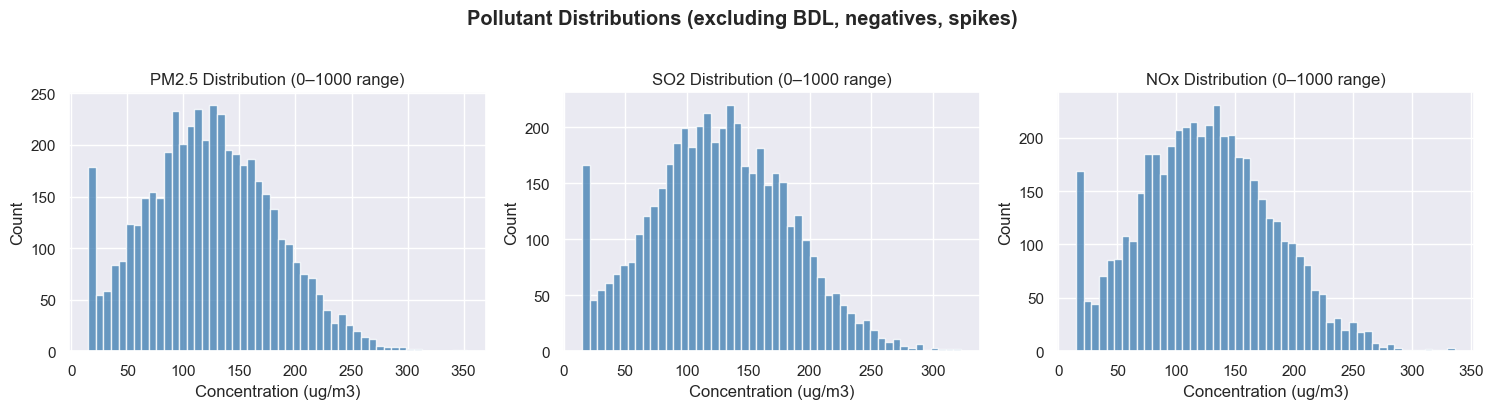

>> ACTION NEEDED:
   - Remove negative values (Rule 5)
   - Replace BDL strings with LOD/2 from sensor_master (Rule 11)
   - Cap/filter spikes using Hampel filter (Rule 8)


In [15]:
# Visualize the normal numeric values (coerce errors to NaN)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(['PM2.5', 'SO2', 'NOx']):
    numeric_vals = pd.to_numeric(raw[col], errors='coerce').dropna()
    # Filter to 'normal' range for readable histogram
    normal_range = numeric_vals[(numeric_vals >= 0) & (numeric_vals <= 1000)]
    
    axes[i].hist(normal_range, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(f'{col} Distribution (0–1000 range)')
    axes[i].set_xlabel('Concentration (ug/m3)')
    axes[i].set_ylabel('Count')

plt.suptitle('Pollutant Distributions (excluding BDL, negatives, spikes)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('>> ACTION NEEDED:')
print('   - Remove negative values (Rule 5)')
print('   - Replace BDL strings with LOD/2 from sensor_master (Rule 11)')
print('   - Cap/filter spikes using Hampel filter (Rule 8)')

## 6. Unit Column Audit

In [16]:
# What unit values exist?
unit_counts = raw['Unit'].value_counts()
print('=== Unit Value Counts ===')
print(unit_counts)
print(f'\nTotal unique values: {raw["Unit"].nunique()}')

# Check for unicode characters
for val in raw['Unit'].unique():
    has_unicode = any(ord(c) > 127 for c in str(val))
    if has_unicode:
        print(f'\nUnicode detected: "{val}" — contains non-ASCII characters')
        print(f'  Char codes: {[f"{c}=U+{ord(c):04X}" for c in str(val) if ord(c) > 127]}')

print(f'\n>> ACTION NEEDED:')
print(f'   - Normalize unicode units to "ug/m3" (Rule 2)')
print(f'   - Convert mg/Nm3 rows: multiply pollutant values * 1000, then fix unit (Rule 14)')

=== Unit Value Counts ===
Unit
ug/m3     4521
mg/Nm3     566
µg/m³      563
Name: count, dtype: int64

Total unique values: 3

Unicode detected: "µg/m³" — contains non-ASCII characters
  Char codes: ['µ=U+00B5', '³=U+00B3']

>> ACTION NEEDED:
   - Normalize unicode units to "ug/m3" (Rule 2)
   - Convert mg/Nm3 rows: multiply pollutant values * 1000, then fix unit (Rule 14)


## 7. Status Column Audit

In [17]:
# What status values exist?
status_counts = raw['Status'].value_counts()
print('=== Status Value Counts ===')
print(status_counts)
print(f'\nTotal unique values: {raw["Status"].nunique()}')

# Detect whitespace issues
for val in raw['Status'].unique():
    stripped = str(val).strip()
    if str(val) != stripped:
        print(f'\nWhitespace issue: "{val}" → should be "{stripped}"')

# Identify canonical vs non-standard
canonical = {'OK', 'FAULT', 'MAINT'}
non_standard = [v for v in raw['Status'].unique() if str(v).strip().upper() not in canonical]
print(f'\nNon-standard status values: {non_standard}')

print(f'\n>> ACTION NEEDED:')
print(f'   - Trim whitespace and normalize casing (Rule 3)')
print(f'   - Map non-standard values to OK/FAULT/MAINT (Rule 12)')

=== Status Value Counts ===
Status
MAINT          1320
OK             1311
FAULT          1307
  MAINT         142
Error 404       130
 fault          130
maintenance     127
ok              126
error           123
 Ok             122
  OK            121
 ok             121
 maint          115
offline         110
OFFLINE         108
DOWN            108
down            103
Name: count, dtype: int64

Total unique values: 17

Whitespace issue: " maint" → should be "maint"

Whitespace issue: "ok " → should be "ok"

Whitespace issue: "  OK  " → should be "OK"

Whitespace issue: " Ok" → should be "Ok"

Whitespace issue: " fault " → should be "fault"

Whitespace issue: " ok " → should be "ok"

Whitespace issue: "DOWN  " → should be "DOWN"

Whitespace issue: "  MAINT " → should be "MAINT"

Non-standard status values: ['error', 'maintenance', 'Error 404', 'down', 'offline', 'OFFLINE', 'DOWN  ', nan]

>> ACTION NEEDED:
   - Trim whitespace and normalize casing (Rule 3)
   - Map non-standard valu

## 8. Lat/Lon Validation

In [18]:
# Parse Lat_Lon and check for issues
def parse_latlon(val):
    """Try to parse a Lat_Lon string. Returns (lat, lon, issue)."""
    if pd.isna(val):
        return None, None, 'null'
    
    s = str(val).strip()
    
    # Try comma-separated
    if ',' in s:
        parts = s.split(',')
    elif ';' in s:
        parts = s.split(';')
        return None, None, f'semicolon separator: {s}'
    else:
        return None, None, f'unparseable: {s}'
    
    if len(parts) != 2:
        return None, None, f'wrong parts count: {s}'
    
    try:
        lat, lon = float(parts[0]), float(parts[1])
    except ValueError:
        return None, None, f'non-numeric: {s}'
    
    # Validate India bounds (Lat: 6-36, Lon: 68-98)
    if not (6 <= lat <= 36):
        return lat, lon, f'lat out of range ({lat})'
    if not (68 <= lon <= 98):
        return lat, lon, f'lon out of range ({lon})'
    
    return lat, lon, None  # No issue

# Apply to all rows
latlon_results = raw['Lat_Lon'].apply(parse_latlon)
issues = [r[2] for r in latlon_results if r[2] is not None]

print(f'=== Lat/Lon Validation ===')
print(f'Total rows:       {len(raw):,}')
print(f'Valid coords:     {len(raw) - len(issues):,}')
print(f'Invalid coords:   {len(issues):,} ({len(issues)/len(raw)*100:.1f}%)')

if issues:
    print(f'\nIssue samples:')
    for issue in issues[:10]:
        print(f'  - {issue}')

print(f'\n>> ACTION NEEDED: Fix {len(issues)} invalid coordinates (Rule 4)')

=== Lat/Lon Validation ===
Total rows:       5,650
Valid coords:     5,558
Invalid coords:   92 (1.6%)

Issue samples:
  - semicolon separator: 12.9718;77.5948
  - lon out of range (-999.0)
  - lat out of range (77.5946)
  - lon out of range (-999.0)
  - lon out of range (-999.0)
  - semicolon separator: 28.62;77.215
  - lon out of range (-999.0)
  - semicolon separator: 19.076;72.8777
  - lat out of range (77.5948)
  - lon out of range (-999.0)

>> ACTION NEEDED: Fix 92 invalid coordinates (Rule 4)


## 9. Gap Detection (Record_ID sequence)

In [19]:
# Extract numeric part from Record_ID (E00001 → 1)
record_nums = raw['Record_ID'].str.extract(r'E(\d+)')[0].astype(int)

# Check for gaps in sequence
full_range = set(range(record_nums.min(), record_nums.max() + 1))
actual_ids = set(record_nums)
missing_ids = sorted(full_range - actual_ids)

print(f'=== Record_ID Gap Analysis ===')
print(f'Expected range: E{record_nums.min():05d} to E{record_nums.max():05d}')
print(f'Expected count: {len(full_range):,}')
print(f'Actual count:   {len(actual_ids):,}')
print(f'Missing IDs:    {len(missing_ids):,} ({len(missing_ids)/len(full_range)*100:.1f}%)')

if missing_ids:
    print(f'\nFirst 20 missing IDs: {[f"E{mid:05d}" for mid in missing_ids[:20]]}')

print(f'\n>> ACTION NEEDED: Generate {len(missing_ids)} filler rows and forward-fill pollutant values (Rule 9)')

=== Record_ID Gap Analysis ===
Expected range: E00001 to E06000
Expected count: 6,000
Actual count:   5,650
Missing IDs:    350 (5.8%)

First 20 missing IDs: ['E00003', 'E00006', 'E00093', 'E00137', 'E00162', 'E00163', 'E00173', 'E00189', 'E00203', 'E00225', 'E00237', 'E00241', 'E00262', 'E00270', 'E00280', 'E00283', 'E00294', 'E00333', 'E00353', 'E00395']

>> ACTION NEEDED: Generate 350 filler rows and forward-fill pollutant values (Rule 9)


## 10. Flow Rate Analysis

In [20]:
# Check Flow_Rate_m3_hr by source type (stack vs ambient)
# Ambient sensors should have 0 or null flow rate
flow_stats = raw.groupby('Stack_ID')['Flow_Rate_m3_hr'].describe()
print('=== Flow Rate by Stack_ID ===')
print(flow_stats)

# Identify ambient sensors (A-XX pattern)
ambient_mask = raw['Stack_ID'].str.startswith('A-')
ambient_flow = raw.loc[ambient_mask, 'Flow_Rate_m3_hr']

print(f'\nAmbient sensor flow rates:')
print(f'  Null: {ambient_flow.isnull().sum()}')
print(f'  Zero: {(ambient_flow == 0).sum()}')
print(f'  Has value: {((ambient_flow > 0) & ambient_flow.notna()).sum()}')
print(f'\n  (Ambient sensors should NOT have flow — city air is not channeled through a chimney)')

=== Flow Rate by Stack_ID ===
           count         mean          std     min       25%      50%     75%     max
Stack_ID                                                                             
A-01       867.0     0.000000     0.000000     0.0     0.000     0.00     0.0     0.0
A-02       284.0     0.000000     0.000000     0.0     0.000     0.00     0.0     0.0
S-01      1689.0  2996.574896  1173.460243  1003.5  1994.700  2961.10  4039.5  4993.3
S-02      1134.0  3013.580159  1155.414413  1002.3  2008.400  3019.65  4048.6  4989.8
S-03       562.0  3074.180783  1170.863216  1004.0  2028.875  3127.80  4082.6  4999.3

Ambient sensor flow rates:
  Null: 1114
  Zero: 1151
  Has value: 0

  (Ambient sensors should NOT have flow — city air is not channeled through a chimney)


## 11. Reference Tables — Sensor Master

In [21]:
# Inspect sensor_master
print('=== sensor_master.csv ===')
print(sensors.to_string(index=False))
print(f'\n{sensors.shape[0]} sensors registered')

=== sensor_master.csv ===
  Plant_ID Stack_ID Source_Type Sector  Zero_Drift  Span_Mult  LOD_PM25  LOD_SO2  LOD_NOx
     PL-01     S-01       Stack Cement         0.5       1.02       2.0      4.0      5.0
     PL-01     S-02       Stack Cement         0.2       0.98       2.0      4.0      5.0
     PL-02     S-01       Stack  Steel        -0.5       1.05       2.0      5.0      5.0
     PL-03     S-01       Stack  Power         0.8       1.10       5.0      5.0      5.0
     PL-03     S-02       Stack  Power         0.1       1.00       5.0      5.0      5.0
     PL-03     S-03       Stack  Power         0.0       1.01       5.0      5.0      5.0
LOC-DEL-01     A-01     Ambient   City         0.1       1.00       1.0      2.0      2.0
LOC-DEL-02     A-02     Ambient   City         0.0       0.99       1.0      2.0      2.0
LOC-MUM-01     A-01     Ambient   City        -0.1       1.02       1.0      2.0      2.0
LOC-BLR-01     A-01     Ambient   City         0.2       1.00       1.0   

In [22]:
# Check: Does every Plant_ID + Stack_ID in raw data exist in sensor_master?
raw_combos = set(zip(raw['Plant_ID'], raw['Stack_ID']))
master_combos = set(zip(sensors['Plant_ID'], sensors['Stack_ID']))

orphaned = raw_combos - master_combos
unused = master_combos - raw_combos

print(f'=== Plant+Stack Mapping Validation ===')
print(f'Combos in raw_data:     {len(raw_combos)}')
print(f'Combos in sensor_master: {len(master_combos)}')
print(f'Orphaned (in raw but not master): {len(orphaned)}')
print(f'Unused (in master but not raw):   {len(unused)}')

if orphaned:
    print(f'\nOrphaned combos: {orphaned}')

print(f'\n>> ACTION NEEDED: Validate all combos match (Rule 13)')

=== Plant+Stack Mapping Validation ===
Combos in raw_data:     10
Combos in sensor_master: 10
Orphaned (in raw but not master): 0
Unused (in master but not raw):   0

>> ACTION NEEDED: Validate all combos match (Rule 13)


## 12. Maintenance Logs — Overlap Check

In [23]:
# Inspect maintenance_logs
print('=== maintenance_logs.csv ===')
print(maint.to_string(index=False))
print(f'\n{maint.shape[0]} maintenance events')

# Check for window durations
maint_copy = maint.copy()
maint_copy['Start'] = pd.to_datetime(maint_copy['Maint_Start'], format='%d-%m-%Y %H:%M')
maint_copy['End'] = pd.to_datetime(maint_copy['Maint_End'], format='%d-%m-%Y %H:%M')
maint_copy['Duration_hrs'] = (maint_copy['End'] - maint_copy['Start']).dt.total_seconds() / 3600

print(f'\nMaintenance window durations (hours):')
print(maint_copy[['Plant_ID', 'Stack_ID', 'Duration_hrs']].to_string(index=False))

print(f'\n>> ACTION NEEDED: Cross-ref with raw_cems — null pollutant values during maintenance windows (Rule 10)')

=== maintenance_logs.csv ===
  Plant_ID Stack_ID      Maint_Start        Maint_End   Technician
     PL-03     S-02 06-01-2025 05:00 06-01-2025 09:00   Ravi Kumar
     PL-01     S-02 01-01-2025 02:00 01-01-2025 04:00 Suresh Patel
LOC-BLR-01     A-01 01-01-2025 10:00 01-01-2025 14:00 Vikram Singh
LOC-MUM-01     A-01 06-01-2025 08:00 06-01-2025 10:00  Anita Verma
     PL-03     S-01 03-01-2025 20:00 03-01-2025 23:00 Vikram Singh
LOC-MUM-01     A-01 04-01-2025 03:00 04-01-2025 06:00 Suresh Patel

6 maintenance events

Maintenance window durations (hours):
  Plant_ID Stack_ID  Duration_hrs
     PL-03     S-02           4.0
     PL-01     S-02           2.0
LOC-BLR-01     A-01           4.0
LOC-MUM-01     A-01           2.0
     PL-03     S-01           3.0
LOC-MUM-01     A-01           3.0

>> ACTION NEEDED: Cross-ref with raw_cems — null pollutant values during maintenance windows (Rule 10)


## 13. Manual Entries — QC & PII Check

In [24]:
# Inspect manual_entries
print('=== manual_entries.csv ===')
print(manual.head(15).to_string(index=False))

=== manual_entries.csv ===
Log_ID   Plant_ID  Lab_PM25_Entry1  Lab_PM25_Entry2                                                       Inspection_Notes
 L0001      PL-01             75.8             76.0 Inspection passed. Signed off by Vikram (vikram.s@gov.in, 9090909090).
 L0002      PL-02             71.7             10.3                          Quarterly calibration completed successfully.
 L0003 LOC-MUM-01            196.1            196.0                         Communication link stable. GPRS signal strong.
 L0004      PL-03            101.0            101.3                          Quarterly calibration completed successfully.
 L0005 LOC-DEL-02             19.6             19.4                            System log reviewed. No anomalies detected.
 L0006 LOC-DEL-02            163.9            164.1                                     Checked laser. System operational.
 L0007      PL-03             69.4             69.1                         Data logger memory at 45%. No action

In [25]:
# Double-entry QC check (Rule 16)
# Compare Lab_PM25_Entry1 vs Entry2 — flag if they differ by > 1%
e1 = manual['Lab_PM25_Entry1']
e2 = manual['Lab_PM25_Entry2']

# Percent difference
avg = (e1 + e2) / 2
pct_diff = (abs(e1 - e2) / avg * 100).round(2)

qc_fail = pct_diff > 1.0
print(f'=== Double-Entry QC Check ===')
print(f'Total entries:   {len(manual)}')
print(f'QC PASS (<=1%):  {(~qc_fail).sum()}')
print(f'QC FAIL (>1%):   {qc_fail.sum()} ({qc_fail.sum()/len(manual)*100:.0f}%)')

if qc_fail.any():
    print(f'\nFailed entries:')
    fail_df = manual[qc_fail][['Log_ID', 'Plant_ID', 'Lab_PM25_Entry1', 'Lab_PM25_Entry2']].copy()
    fail_df['Pct_Diff'] = pct_diff[qc_fail]
    print(fail_df.to_string(index=False))

print(f'\n>> ACTION NEEDED: Flag {qc_fail.sum()} entries as QC_FAIL (Rule 16)')

=== Double-Entry QC Check ===
Total entries:   10
QC PASS (<=1%):  8
QC FAIL (>1%):   2 (20%)

Failed entries:
Log_ID   Plant_ID  Lab_PM25_Entry1  Lab_PM25_Entry2  Pct_Diff
 L0002      PL-02             71.7             10.3    149.76
 L0005 LOC-DEL-02             19.6             19.4      1.03

>> ACTION NEEDED: Flag 2 entries as QC_FAIL (Rule 16)


In [26]:
# PII scan (Rule 18) — check for phone numbers and emails in notes
phone_pattern = r'\b\d{10}\b'
email_pattern = r'[\w.-]+@[\w.-]+\.\w+'

has_phone = manual['Inspection_Notes'].str.contains(phone_pattern, na=False, regex=True)
has_email = manual['Inspection_Notes'].str.contains(email_pattern, na=False, regex=True)
has_pii = has_phone | has_email

print(f'=== PII Scan in Inspection Notes ===')
print(f'Total notes:       {len(manual)}')
print(f'Contains phone #:  {has_phone.sum()}')
print(f'Contains email:    {has_email.sum()}')
print(f'Total with PII:    {has_pii.sum()} ({has_pii.sum()/len(manual)*100:.0f}%)')

if has_pii.any():
    print(f'\nSamples with PII:')
    for note in manual.loc[has_pii, 'Inspection_Notes'].head(5):
        print(f'  "{note}"')

print(f'\n>> ACTION NEEDED: Redact phone numbers and emails with [REDACTED] (Rule 18)')

=== PII Scan in Inspection Notes ===
Total notes:       10
Contains phone #:  2
Contains email:    2
Total with PII:    2 (20%)

Samples with PII:
  "Inspection passed. Signed off by Vikram (vikram.s@gov.in, 9090909090)."
  "System broken. Call Amit at 9876543210 or amit@email.com."

>> ACTION NEEDED: Redact phone numbers and emails with [REDACTED] (Rule 18)


## 14. Regulatory Thresholds — Quick Look

In [27]:
# Inspect thresholds
print('=== regulatory_thresholds.csv ===')
print(thresholds.to_string(index=False))
print(f'\nThese are the legal limits we will check cleaned data against (Rule 19).')
print(f'Note: Stack limits are much higher than Ambient — this is why Rule 15 (source tagging) must run BEFORE Rule 19.')

=== regulatory_thresholds.csv ===
Pollutant Source_Type  Legal_Limit_ugm3
    PM2.5     Ambient              60.0
    PM2.5       Stack             150.0
      SO2     Ambient              80.0
      SO2       Stack             200.0
      NOx     Ambient              80.0
      NOx       Stack             400.0

These are the legal limits we will check cleaned data against (Rule 19).
Note: Stack limits are much higher than Ambient — this is why Rule 15 (source tagging) must run BEFORE Rule 19.


---
## 15. SUMMARY OF ALL FINDINGS
Every data quality issue discovered, with the action needed.

In [28]:
# Build summary table
findings = [
    ['TS: Hour=24 timestamps', count_24, f'{pct_24}%', 'Roll to next day 00:xx', 'R1'],
    ['TS: UTC suffix', count_utc, f'{pct_utc}%', 'Convert to IST (+5:30)', 'R17'],
    ['Unit: Unicode chars', int((raw['Unit'].str.contains('\u00b5|\u00b3', na=False, regex=True)).sum()), '', 'Normalize to ug/m3', 'R2'],
    ['Unit: mg/Nm3', int((raw['Unit'] == 'mg/Nm3').sum()), '', 'Multiply values * 1000, fix unit', 'R14'],
    ['Status: Whitespace/messy', int(sum(1 for v in raw['Status'] if str(v).strip().upper() not in canonical)), '', 'Trim + map to canonical', 'R3, R12'],
    ['Pollutants: Negatives', '~5% each', '', 'Flag and discard', 'R5'],
    ['Pollutants: BDL strings', '~5% each', '', 'Replace with LOD/2', 'R11'],
    ['Pollutants: Spikes >5000', '~3% each', '', 'Hampel filter', 'R8'],
    ['Record_ID: Gaps', len(missing_ids), f'{len(missing_ids)/len(full_range)*100:.1f}%', 'Insert filler rows + forward-fill', 'R9'],
    ['Lat_Lon: Invalid coords', len(issues), f'{len(issues)/len(raw)*100:.1f}%', 'Parse and validate bounds', 'R4'],
    ['Manual: QC failures', qc_fail.sum(), f'{qc_fail.sum()/len(manual)*100:.0f}%', 'Flag as QC_FAIL', 'R16'],
    ['Manual: PII in notes', has_pii.sum(), f'{has_pii.sum()/len(manual)*100:.0f}%', 'Regex redact', 'R18'],
]

summary_df = pd.DataFrame(findings, columns=['Issue', 'Count', 'Pct', 'Action', 'Rule'])
print('=' * 90)
print('  DATA QUALITY ISSUE SUMMARY')
print('=' * 90)
print(summary_df.to_string(index=False))
print('=' * 90)
print(f'\nAdditional rules to apply (no explicit "messy" data but still needed):')
print(f'  R6:  Duplicate detection by Plant_ID + TS')
print(f'  R7:  Zero/Span calibration (sensor_master drift correction)')
print(f'  R10: Maintenance downtime cross-reference')
print(f'  R13: Plant+Stack mapping validation')
print(f'  R15: Ambient vs Stack source tagging')
print(f'  R19: Regulatory threshold exceedance flagging')
print(f'  R20: Audit trail (change log + SHA-256 integrity hash)')

  DATA QUALITY ISSUE SUMMARY
                   Issue    Count   Pct                            Action    Rule
  TS: Hour=24 timestamps      155 2.74%            Roll to next day 00:xx      R1
          TS: UTC suffix      283 5.01%            Convert to IST (+5:30)     R17
     Unit: Unicode chars      563                      Normalize to ug/m3      R2
            Unit: mg/Nm3      566        Multiply values * 1000, fix unit     R14
Status: Whitespace/messy      835                 Trim + map to canonical R3, R12
   Pollutants: Negatives ~5% each                        Flag and discard      R5
 Pollutants: BDL strings ~5% each                      Replace with LOD/2     R11
Pollutants: Spikes >5000 ~3% each                           Hampel filter      R8
         Record_ID: Gaps      350  5.8% Insert filler rows + forward-fill      R9
 Lat_Lon: Invalid coords       92  1.6%         Parse and validate bounds      R4
     Manual: QC failures        2   20%                   Flag as QC_

---
### Next Step
All issues documented. Proceed to **`02_cleaning.ipynb`** to apply the 20 cleaning rules in dependency order.